# Create your own hydrologic zone

In `3_Create_Model_Structure.py` we assembled *existing* zones into our own
model. Here we go one step further and add a zone that does not exist in
`potions` at all: a groundwater reservoir that is **pumped**, i.e. it loses a
fixed amount of water each day to represent water extraction for supply.

The new zone, `PumpedGroundZoneB`, behaves like the built-in `GroundZoneB`
(a linear reservoir that discharges to the stream proportionally to its
storage) but with an extra outflow that removes up to `pump_rate` of storage
every day. We drop it into the same five-zone, two-column structure from the
previous notebook (a hillslope and a riparian column above one shared
groundwater store) so we can compare a pumped against an unpumped system.

The steps are:

1. Load the downloaded input hydrology data
2. Construct the forcing data object(s)
3. Define the physical behavior of the new zone
4. Implement the new `HydrologicZone` subclass in Python
5. Build the model with the pumped groundwater zone
6. Run the simulation
7. View the model outputs
8. Plot the results, highlighting the pumping and how it dries out the store

As with the previous scripts, this is a Jupytext-style percent script: code
cells are delimited by `# %%` and text cells by `# %% [markdown]`.

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from pandas import DataFrame, Series

import potions as pt
from potions.core import HydroForcing, HydroStep

data_dir: str = "../data"
forcing_path: str = os.path.join(data_dir, "model_inputs", "forcing.csv")
measured_path: str = os.path.join(data_dir, "model_inputs", "measured_data.csv")

## 1. Load the input hydrology data

This is the same data used in the previous notebooks: daily forcing
(`ppt`, `temp`, `pet`) and the observed streamflow (`q_mmd`). We read both
into DataFrames with a parsed datetime index.

In [2]:
forcing_df: DataFrame = pd.read_csv(forcing_path, index_col=0, parse_dates=True)
measured_df: DataFrame = pd.read_csv(measured_path, index_col=0, parse_dates=True)

print(
    f"Forcing spans {forcing_df.index[0].date()} to {forcing_df.index[-1].date()} ({len(forcing_df)} days)"
)
print(
    f"Measured streamflow spans {measured_df.index[0].date()} to {measured_df.index[-1].date()} ({len(measured_df)} days)"
)

forcing_df.head()

Forcing spans 2008-10-01 to 2015-09-30 (2554 days)
Measured streamflow spans 2009-10-01 to 2015-09-30 (2191 days)


,ppt,temp,pet
time,,,
2008-10-01,3.5,10.500000,2.4
2008-10-02,2.2,5.500000,2.0
2008-10-03,1.6,4.899994,2.2
2008-10-04,0.0,5.100006,2.4
2008-10-05,0.0,7.149994,1.8


## 2. Construct the input forcing data object

The model has **two surface zones** (the hillslope and the riparian zone), so
it expects **two** `pt.ForcingData` objects - one per column. As before we use
the same daily drivers for both columns; a real application could apply
lapse-rate scaling to give each column its own series.

In [3]:
hs_forcing: pt.ForcingData = pt.ForcingData(
    precip=forcing_df["ppt"], temp=forcing_df["temp"], pet=forcing_df["pet"]
)
rp_forcing: pt.ForcingData = pt.ForcingData(
    precip=forcing_df["ppt"], temp=forcing_df["temp"], pet=forcing_df["pet"]
)

# A list of ForcingData objects, one per surface column, ordered [hillslope, riparian].
forcing_list: list[pt.ForcingData] = [hs_forcing, rp_forcing]

meas_streamflow: Series = measured_df["q_mmd"]
print(f"Number of surface forcing series: {len(forcing_list)}")
print(f"Number of measured streamflow values: {len(meas_streamflow)}")

Number of surface forcing series: 2
Number of measured streamflow values: 2191


## 3. What the new zone is designed to do

The built-in `GroundZoneB` is a *linear reservoir*: its lateral (stream)
outflow is

$$\text{outflow} = k \, s^{\alpha},$$

where `s` is the storage in the zone and `k` and `alpha` are parameters.
In addition to that discharge, we want the water table to be lowered by
**pumping**, so the zone loses a further, constant amount of water each
day:

$$\text{pump} = \min(s,\ \text{pump\_rate}).$$

The `min` guard matters: a pump can only extract the water that is actually
there. If the store runs low in a dry spell, the pump delivers less (or
nothing) instead of driving the storage negative - exactly how a real
groundwater pump behaves when a well dries out.

We treat the pump as a "vaporizes-like" outflow in the zone's water balance
(it removes water from the store but does not flow elsewhere in the model),
which is why it is added to `vap_flux`. The complete daily update for the
storage is then an explicit-Euler step:

$$s_{t+1} = s_t + \Delta t \; \big( q_{in} + \text{forc}
  - \text{vap} - \text{lat} - \text{vert} \big),$$

floored at zero so the storage can never become negative.

`potions` represents each model box as a `pt.HydrologicZone`. To add our own
kind of box we subclass that base class and tell it, for any given storage
`s` and forcing record `d`, what each flux is, what parameters it has, and
how to advance the storage by one timestep.

In [4]:
# The physical parameters of the pumped groundwater zone. These are the *tuned*
# values used for the main run below; the zone class also carries gentle
# defaults so a bare placeholder instance is still valid.
k_ground: float = 0.01  # linear-reservoir runoff coefficient (1/d)
alpha_ground: float = 1.5  # runoff exponent (dimensionless)
pump_rate: float = 0.30  # maximum amount of water pumped each day (mm/d)

## 4. Implement the new zone in Python

We subclass `pt.HydrologicZone`. Three small implementation details are worth
calling out because they are specific to `potions` being built in Rust (PyO3):

- The constructor's `name` argument is handled by the Rust layer, so we
  override `__new__` to take just the name and let Python's `__init__` assign
  our own parameters (`k`, `alpha`, `pump_rate`) as ordinary attributes.
- Every flux method receives the current storage `s` and a `HydroForcing`
  record `d`; they must each return a single `float`.
- `default()` is what the model uses to stand in for a zone when we do not
  supply one; it must return an instance of *this* class, otherwise our
  custom physics would silently be replaced by a build-in.

In [5]:
class PumpedSubsurfaceZoneB(pt.HydrologicZone):
    """A linear groundwater reservoir (a `SubsurfaceZoneB`) that also loses a fixed
    amount of water each day to represent pumping.

    The lateral outflow is ``k * s**alpha``, and the pump removes up to
    ``pump_rate`` of storage per day, capped by the water actually available so
    the storage can never become negative.
    """

    def __new__(
        cls, name: str = "pumped_ground", **kwargs: float
    ) -> "PumpedSubsurfaceZoneB":
        # The Rust (PyO3) __new__ accepts only the positional `name`; strip our
        # keyword parameters so they do not get forwarded to it.
        return super().__new__(cls, name)

    def __init__(
        self,
        k: float = 0.01,
        alpha: float = 1.0,
        pump_rate: float = 0.0,
        name: str = "pumped_ground",
    ) -> None:
        # `name` is already set by __new__; we only assign our own parameters.
        self.k: float = k
        self.alpha: float = alpha
        self.pump_rate: float = pump_rate

    # ---- Flux terms -------------------------------------------------------
    def forc_flux(self, s: float, d: HydroForcing) -> float:
        """External precipitation added directly to this zone (none for groundwater)."""
        return 0.0

    def vap_flux(self, s: float, d: HydroForcing) -> float:
        """Pumping: removes up to `pump_rate` of storage, capped by what is stored."""
        return min(s, self.pump_rate)

    def lat_flux(self, s: float, d: HydroForcing) -> float:
        """Linear-reservoir discharge to the stream: k * s**alpha."""
        return self.k * (s**self.alpha)

    def vert_flux(self, s: float, d: HydroForcing) -> float:
        """Vertical (downward) flux (none - this is the bottom zone)."""
        return 0.0

    # ---- External (report) fluxes ---------------------------------------
    # The model reports these as the zone's contribution to the outlet stream;
    # we mirror the internal lateral flux so it shows up as streamflow.
    def lat_flux_ext(self, s: float, d: HydroForcing) -> float:
        """Lateral flux reported to the river (equals the internal lateral flux)."""
        return self.lat_flux(s, d)

    def vert_flux_ext(self, s: float, d: HydroForcing) -> float:
        """Vertical flux reported to the river (none)."""
        return 0.0

    # ---- Water balance & state update ------------------------------------
    def mass_balance(self, s: float, d: HydroForcing) -> float:
        """Net rate of change of storage (the source term of the Euler step)."""
        return (
            d.q_in
            + self.forc_flux(s, d)
            - self.vap_flux(s, d)
            - self.lat_flux(s, d)
            - self.vert_flux(s, d)
        )

    def step(self, s_0: float, d: HydroForcing, dt: float) -> HydroStep:
        """Advance the storage one timestep with an explicit-Euler update."""
        s_new: float = s_0 + dt * self.mass_balance(s_0, d)
        s_new = max(0.0, s_new)  # storage can never be negative
        return HydroStep(
            state=s_new,
            forc_flux=self.forc_flux(s_0, d),
            lat_flux=self.lat_flux(s_0, d),
            vert_flux=self.vert_flux(s_0, d),
            vap_flux=self.vap_flux(s_0, d),
            q_in=d.q_in,
            lat_flux_ext=self.lat_flux_ext(s_0, d),
            vert_flux_ext=self.vert_flux_ext(s_0, d),
        )

    # ---- Parameter bookkeeping (used for to_dict / optimisation) ---------
    def param_list(self) -> list[float]:
        """The parameter values in the fixed order used by `parameter_names`."""
        return [self.k, self.alpha, self.pump_rate]

    @classmethod
    def parameter_names(cls) -> list[str]:
        """The names of the parameters, matching the order of `param_list`."""
        return ["k", "alpha", "pump_rate"]

    @classmethod
    def num_parameters(cls) -> int:
        """The number of tunable parameters."""
        return 3

    @classmethod
    def default_init_state(cls) -> float:
        """A sensible initial groundwater storage (mm) for a cold run."""
        return 10.0

    @classmethod
    def default(cls) -> "PumpedSubsurfaceZoneB":
        """A placeholder instance with gentle defaults (no pumping)."""
        return cls(k=0.01, alpha=1.0, pump_rate=0.0, name="ground")


# A quick, unit-style check of the new zone before we plug it into a model.
test_forcing: HydroForcing = HydroForcing(precip=0.0, temp=10.0, pet=0.0, q_in=2.0)
test_zone: PumpedSubsurfaceZoneB = PumpedSubsurfaceZoneB(
    k=k_ground, alpha=alpha_ground, pump_rate=pump_rate
)
print("probe zone name:", test_zone.name)
print("parameters (k, alpha, pump_rate):", test_zone.param_list())
print("pump at s=5.0 (well full): ", test_zone.vap_flux(5.0, test_forcing))
print("pump at s=0.1 (well drying):", test_zone.vap_flux(0.1, test_forcing))
print("stream discharge at s=5.0: ", test_zone.lat_flux(5.0, test_forcing))
print("mass balance at s=5.0:     ", test_zone.mass_balance(5.0, test_forcing))
print("one-day step from s=5.0 -> ", test_zone.step(5.0, test_forcing, 1.0))

probe zone name: pumped_ground
parameters (k, alpha, pump_rate): [0.01, 1.5, 0.3]
pump at s=5.0 (well full):  0.3
pump at s=0.1 (well drying): 0.1
stream discharge at s=5.0:  0.1118033988749895
mass balance at s=5.0:      1.5881966011250104
one-day step from s=5.0 ->  HydroStep(
	state=6.59,
	forc_flux=0.00,
	lat_flux=0.11,
	vert_flux=0.00,
	vap_flux=0.30,
	q_in=2.00,
	lat_flux_ext=0.11,
	vert_flux_ext=0.00)


## 5. Build the model with the pumped groundwater zone

`PumpedTwinColumnModel` is just the structure from `3_Create_Model_Structure.py`,
with the built-in `GroundZoneB` replaced by our new `PumpedGroundZoneB`. The
placeholder zone inside this list matters for two reasons: it reserves the
name `ground`, and the model reads its `param_list()`, `parameter_names()` and
`default_init_state()` to know how many parameters each box holds and how to
start the simulation.

We then create a *tuned* instance and hand it to the model constructor via the
`zones` dictionary (keyed by the zone name). That is how a model swaps in a
custom-parameterised zone: the structure names the box, and `zones` supplies
the actual object to use.

In [6]:
class PumpedTwinColumnModel(pt.Model):
    """The five-zone hillslope/riparian model, but with a *pumped* groundwater
    reservoir (our custom `PumpedSubsurfaceZoneB`) at the bottom."""

    structure: list[list[pt.HydrologicZone]] = [
        [pt.SnowZone(name="snow_hs"), pt.SnowZone(name="snow_rp")],
        [pt.SurfaceZone(name="surface_hs"), pt.SurfaceZone(name="surface_rp")],
        [PumpedSubsurfaceZoneB(name="ground")],  # placeholder class + default params
    ]

    @property
    def snow_hs(self) -> pt.SnowZone:
        return self.hydro_zones["snow_hs"]  # type: ignore

    @property
    def snow_rp(self) -> pt.SnowZone:
        return self.hydro_zones["snow_rp"]  # type: ignore

    @property
    def surface_hs(self) -> pt.SurfaceZone:
        return self.hydro_zones["surface_hs"]  # type: ignore

    @property
    def surface_rp(self) -> pt.SurfaceZone:
        return self.hydro_zones["surface_rp"]  # type: ignore

    @property
    def ground(self) -> PumpedSubsurfaceZoneB:
        return self.hydro_zones["ground"]  # type: ignore


# Fractional catchment area of each surface column (must sum to 1).
hillslope_scale: float = 0.7
riparian_scale: float = 0.3
scales: list[float] = [hillslope_scale, riparian_scale]

# The tuned groundwater zone we actually want to run (with real pumping). This
# is the object the model will use for the box named "ground".
pumped_ground: PumpedSubsurfaceZoneB = PumpedSubsurfaceZoneB(
    k=k_ground, alpha=alpha_ground, pump_rate=pump_rate, name="ground"
)

custom_zones: dict[str, pt.HydrologicZone] = {"ground": pumped_ground}

model: PumpedTwinColumnModel = PumpedTwinColumnModel(zones=custom_zones, scales=scales)

print("Zones in the model (top to bottom):")
for zone_name in model.get_zone_names():
    print(f"  - {zone_name}: {model[zone_name].__class__.__name__}")
print(f"Surface columns: {model.num_surface_zones}, scales: {model.scales}")
print()
print("Complete parameterisation (notice the three 'ground.*' parameters):")
model.to_dict()

Zones in the model (top to bottom):
  - snow_hs: SnowZone
  - snow_rp: SnowZone
  - surface_hs: SurfaceZone
  - surface_rp: SurfaceZone
  - ground: PumpedSubsurfaceZoneB
Surface columns: 2, scales: [0.7, 0.3]

Complete parameterisation (notice the three 'ground.*' parameters):


{'snow_hs.tt': np.float64(0.0),
 'snow_hs.fmax': np.float64(1.0),
 'snow_rp.tt': np.float64(0.0),
 'snow_rp.fmax': np.float64(1.0),
 'surface_hs.fc': np.float64(100.0),
 'surface_hs.lp': np.float64(0.5),
 'surface_hs.beta': np.float64(1.0),
 'surface_hs.k0': np.float64(0.1),
 'surface_hs.thr': np.float64(10.0),
 'surface_rp.fc': np.float64(100.0),
 'surface_rp.lp': np.float64(0.5),
 'surface_rp.beta': np.float64(1.0),
 'surface_rp.k0': np.float64(0.1),
 'surface_rp.thr': np.float64(10.0),
 'ground.k': np.float64(0.01),
 'ground.alpha': np.float64(1.5),
 'ground.pump_rate': np.float64(0.3),
 'proportion.1': np.float64(0.7)}

## 6. Run the simulation

As in the previous notebooks, we step the model forward in time, passing one
forcing series per column and the observed streamflow so the run also reports
performance metrics.

In [7]:
hydro_res: pt.HydroModelResults = model.run_hydro_model(
    forc=forcing_list,
    meas_streamflow=meas_streamflow,
)

print("Simulation complete.")

Simulation complete.


## 7. View the model outputs

`run_hydro_model` returns a `pt.HydroModelResults`. Its `simulation` DataFrame
has one block of eight columns per zone - `s_<zone>` (storage) plus the
`q_forc`, `q_vap`, `q_lat`, `q_vert`, `q_in`, `q_lat_ext`, and `q_vert_ext`
fluxes - followed by `streamflow_sim`, `meas_streamflow`, and one
`prop_q_<zone>` column per zone giving its fraction of the simulated stream.
With five zones that is 5 x 8 + 2 + 3 = 45 columns.

The columns that matter for the pump are:

- `q_vap_ground` is the **pumping** flux - exactly the `min(s, pump_rate)` we
  programmed into `vap_flux`.
- `s_ground` is the groundwater storage; pumping keeps pressing it downward.
- `q_in_ground` is the water arriving from the two surface columns above.

In [8]:
print("Performance metrics:")
print(hydro_res.objective_functions)
print()

simulation_df: DataFrame = hydro_res.simulation
print(f"Simulation output shape: {simulation_df.shape}")
print()

# A few numbers that summarise the effect of pumping:
print(
    f"Pump flux  : mean {simulation_df['q_vap_ground'].mean():.4f}, "
    f"max {simulation_df['q_vap_ground'].max():.4f} mm/d"
)
print(
    f"Groundwater: min  {simulation_df['s_ground'].min():.4f}, "
    f"mean {simulation_df['s_ground'].mean():.4f} mm"
)

simulation_df.head()

Performance metrics:
kge             0.265408
log_kge         0.399342
nse             0.104493
log_nse        -0.249262
bias            0.163171
spearman_rho    0.636190
r_squared       0.162014
dtype: float64

Simulation output shape: (2554, 45)

Pump flux  : mean 0.2829, max 0.3000 mm/d
Groundwater: min  0.0000, mean 26.4208 mm


,s_snow_hs,q_forc_snow_hs,q_vap_snow_hs,q_lat_snow_hs,q_vert_snow_hs,q_in_snow_hs,q_lat_ext_snow_hs,q_vert_ext_snow_hs,s_snow_rp,q_forc_snow_rp,...,q_lat_ground,q_vert_ground,q_in_ground,q_lat_ext_ground,q_vert_ext_ground,streamflow_sim,meas_streamflow_mmd,prop_q_snow_rp,prop_q_surface_rp,prop_q_ground
time,,,,,,,,,,,,,,,,,,,,,
2008-10-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.45,0.0,0.0,...,0.316228,0.0,1.228961,0.316228,0.0,1.817979,NaN,0.0,0.826055,0.173945
2008-10-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.54,0.0,0.0,...,0.345733,0.0,0.868092,0.345733,0.0,1.822816,NaN,0.0,0.810330,0.189670
2008-10-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.12,0.0,0.0,...,0.356655,0.0,0.677072,0.356655,0.0,1.790052,NaN,0.0,0.800757,0.199243
2008-10-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.357664,0.0,0.254305,0.357664,0.0,1.705373,NaN,0.0,0.790272,0.209728
2008-10-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.337916,0.0,0.213350,0.337916,0.0,1.606913,NaN,0.0,0.789711,0.210289


## 8. Plot the results

We focus on what changes because of the pump. Panel A shows the groundwater
storage (with the pump keeping it low), panel B shows the pump operating at
full rate and then "running dry" when the store falls short of `pump_rate`,
and panel C compares the simulated to the measured streamflow.

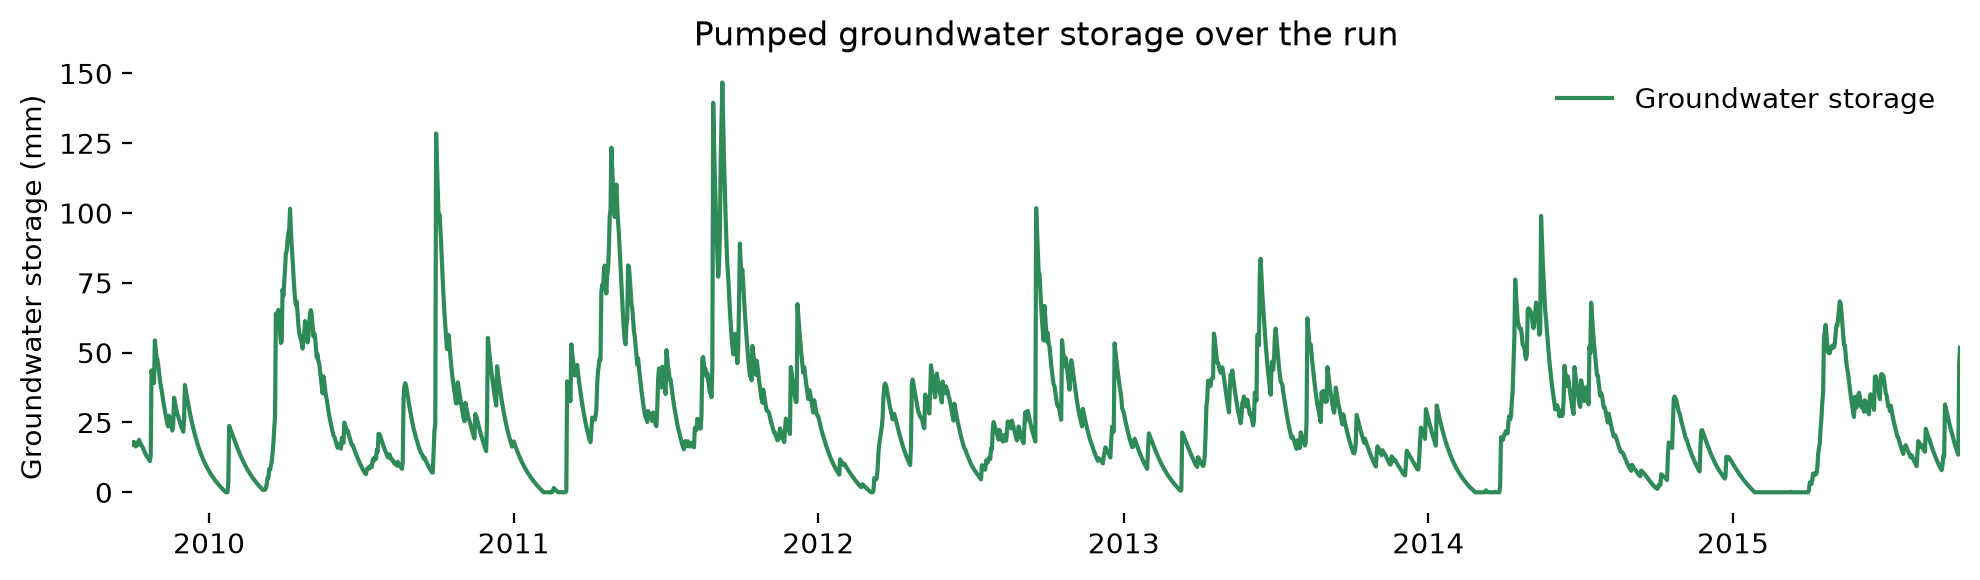

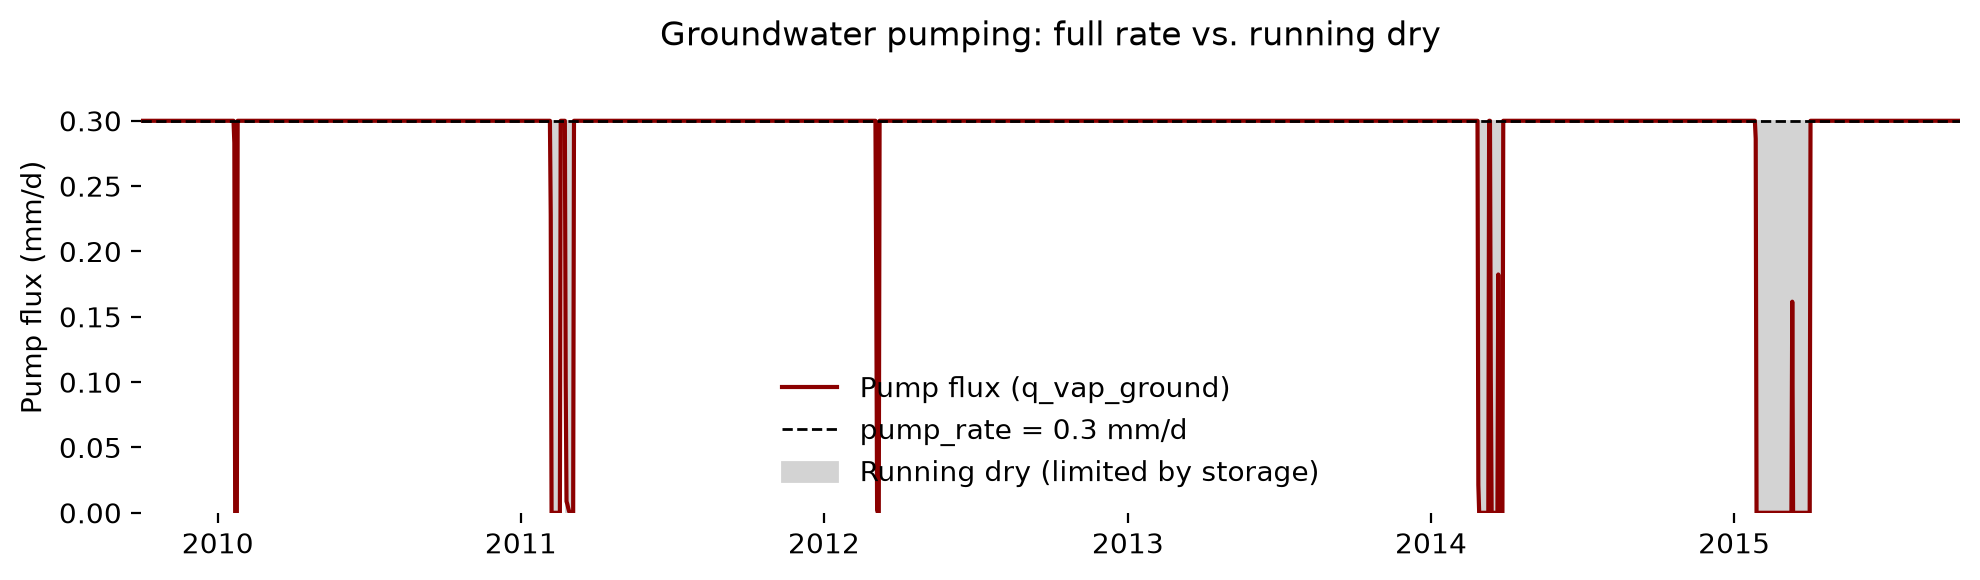

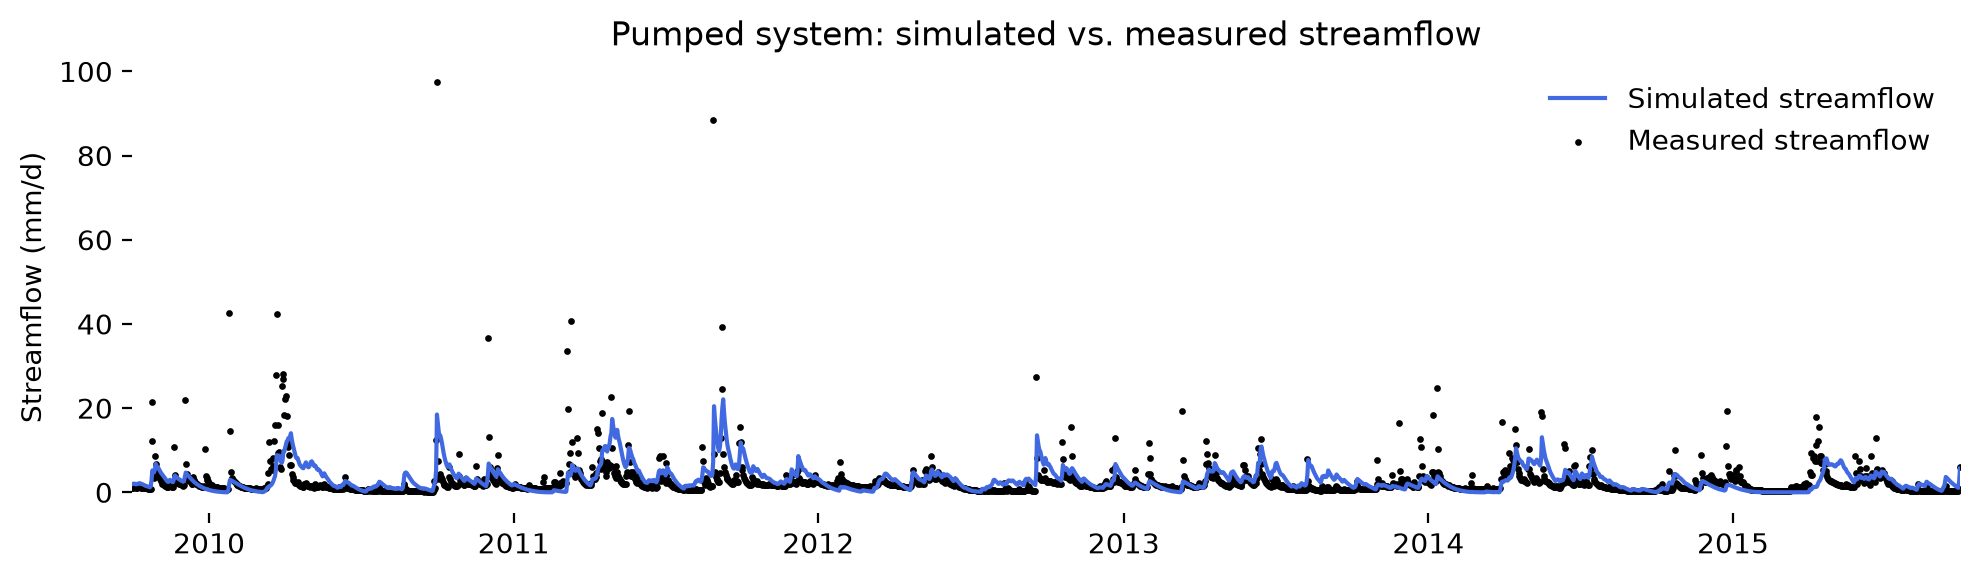

In [9]:
plt.rcParams["figure.dpi"] = 200
plt.rcParams["legend.frameon"] = False
plt.rcParams["axes.spines.bottom"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.left"] = False
plt.rcParams["axes.spines.right"] = False

obs_start: pd.Timestamp = meas_streamflow.index[0]
obs_end: pd.Timestamp = meas_streamflow.index[-1]

# ---- Panel A: groundwater storage over the run ---- #
fig_a: Figure = plt.figure(figsize=(10, 3))
ax_a: Axes = fig_a.gca()
ax_a.plot(
    simulation_df.index,
    simulation_df["s_ground"],
    color="seagreen",
    label="Groundwater storage",
)
ax_a.set_xlim(obs_start, obs_end)
ax_a.set_ylabel("Groundwater storage (mm)")
ax_a.set_title("Pumped groundwater storage over the run")
ax_a.legend()
fig_a.tight_layout()
plt.show()

# ---- Panel B: the pump - full rate vs. running dry ---- #
fig_b: Figure = plt.figure(figsize=(10, 3))
ax_b: Axes = fig_b.gca()
ax_b.plot(
    simulation_df.index,
    simulation_df["q_vap_ground"],
    color="darkred",
    label="Pump flux (q_vap_ground)",
)
ax_b.axhline(
    pump_rate,
    color="black",
    linestyle="--",
    linewidth=1,
    label=f"pump_rate = {pump_rate} mm/d",
)
ax_b.fill_between(
    simulation_df.index,
    0,
    pump_rate,
    where=(simulation_df["q_vap_ground"] < pump_rate),
    color="lightgray",
    label="Running dry (limited by storage)",
)
ax_b.set_xlim(obs_start, obs_end)
ax_b.set_ylim(0, pump_rate * 1.15)
ax_b.set_ylabel("Pump flux (mm/d)")
ax_b.set_title("Groundwater pumping: full rate vs. running dry")
ax_b.legend()
fig_b.tight_layout()
plt.show()

# ---- Panel C: simulated vs. measured streamflow ---- #
fig_c: Figure = plt.figure(figsize=(10, 3))
ax_c: Axes = fig_c.gca()
ax_c.plot(
    simulation_df.index,
    simulation_df["streamflow_sim"],
    color="royalblue",
    label="Simulated streamflow",
)
ax_c.scatter(
    meas_streamflow.index,
    meas_streamflow,
    s=2,
    color="black",
    label="Measured streamflow",
)
ax_c.set_xlim(obs_start, obs_end)
ax_c.set_ylabel("Streamflow (mm/d)")
ax_c.set_title("Pumped system: simulated vs. measured streamflow")
ax_c.legend()
fig_c.tight_layout()
plt.show()